In [57]:
!pip install -q transformers datasets evaluate peft bitsandbytes accelerate scikit-learn

In [58]:
# Фиксирование random seed
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Выбран датасет data-silence/fasttext-rus-news-classifier для класификации русскоязычных новостей

In [59]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np

model_name = "cointegrated/rubert-tiny2"

dataset = load_dataset("data-silence/rus_news_classifier")
print(f"Датасет загружен. Размеры: train={len(dataset['train'])}, test={len(dataset['test'])}")

print("\nСтруктура датасета:")
print("Столбцы в train:", dataset['train'].column_names)
print("Пример данных из train:", dataset['train'][0])

num_labels = len(set(dataset['train']['labels']))
print(f"Количество классов: {num_labels}")

# Проверка баланса классов
from collections import Counter
train_labels = Counter(dataset['train']['labels'])
print("Баланс классов в train:", train_labels)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["news"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

Датасет загружен. Размеры: train=57530, test=14383

Структура датасета:
Столбцы в train: ['news', 'labels']
Пример данных из train: {'news': 'Житель Москвы сходил на сеанс эротического массажа, после которого умер. Об этом сообщает Telegram-канал Mash. По информации издания, 31-летний москвич заказывал сеанс массажа с последующими интимными услугами в квартире на бульваре Яна Райниса. Через некоторое время тело мужчины обнаружили в ванной. Жители дома рассказали полиции, что квартира сдавалась посуточно, и в ней регулярно проходили не только аналогичные сеансы, но и вечеринки, сообщает канал. Точную причину смерти москвича определят следователи. Ранее трое жителей Чечни, чьи личности не раскрываются, пропали после оргии в Грозном. Во время вечеринки компания из четырех человек активно снимала видео, в том числе процесс употребления неизвестного порошка.', 'labels': 1}
Количество классов: 11
Баланс классов в train: Counter({4: 7993, 1: 6277, 3: 5636, 6: 5558, 7: 5406, 8: 4937, 5: 4931, 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [60]:
# Глобальное отключение wandb для автоматического выполнения
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "dryrun"

try:
    import wandb
    wandb.init(mode="disabled")
except:
    pass


In [61]:
training_args = TrainingArguments(
    output_dir="./results_as_is",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
    seed=RANDOM_SEED,
    report_to="none",
    disable_tqdm=False  # Показывать прогресс-бар
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# Оценка качества модели без дообучения
print("Оценка качества модели as-is...")
eval_results_as_is = trainer.evaluate()
print(f"Результаты as-is: {eval_results_as_is}")

# Сохранение результатов для сравнения
results = {
    "as_is": eval_results_as_is
}

Оценка качества модели as-is...


Результаты as-is: {'eval_loss': 2.409127950668335, 'eval_model_preparation_time': 0.0009, 'eval_accuracy': 0.06980463046652298, 'eval_runtime': 6.1364, 'eval_samples_per_second': 2343.885, 'eval_steps_per_second': 146.503}


Настройки для полного дообучения

In [67]:
# Убедимся, что словарь results существует
if 'results' not in globals():
    results = {}

model_full = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

# Настройки обучения с совместимыми аргументами
training_args_full = TrainingArguments(
    output_dir="./results_full",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=RANDOM_SEED,
    report_to="none",
    disable_tqdm=False
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Начало полного дообучения...")
train_results_full = trainer_full.train()

eval_results_full = trainer_full.evaluate()
print(f"Результаты полного дообучения: {eval_results_full}")

results["full_finetuning"] = eval_results_full

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Начало полного дообучения...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.493500,0.463864,0.850170
2,0.394300,0.418944,0.864979
3,0.328500,0.410730,0.865605


Результаты полного дообучения: {'eval_loss': 0.41072985529899597, 'eval_accuracy': 0.8656052283946325, 'eval_runtime': 5.7763, 'eval_samples_per_second': 2489.983, 'eval_steps_per_second': 155.635, 'epoch': 3.0}


Загрузка модели для linear probing

In [68]:
# Создание модели для linear probing
model_lp = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

# Заморозка всех слоев кроме классификационного головы
for name, param in model_lp.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

training_args_lp = TrainingArguments(
    output_dir="./results_lp",
    learning_rate=5e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=RANDOM_SEED,
    report_to="none",
    disable_tqdm=False
)

trainer_lp = Trainer(
    model=model_lp,
    args=training_args_lp,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Начало linear probing...")
train_results_lp = trainer_lp.train()

eval_results_lp = trainer_lp.evaluate()
print(f"Результаты linear probing: {eval_results_lp}")

results["linear_probing"] = eval_results_lp

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Начало linear probing...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.083500,1.021355,0.696517
2,0.965700,0.903254,0.720990
3,0.927100,0.878899,0.726413


Результаты linear probing: {'eval_loss': 0.8788992166519165, 'eval_accuracy': 0.7264131266078009, 'eval_runtime': 5.9797, 'eval_samples_per_second': 2405.313, 'eval_steps_per_second': 150.343, 'epoch': 3.0}


Дообучение с LoRa

In [69]:
from peft import LoraConfig, get_peft_model, TaskType

model_lora = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # Sequence classification
    r=8,                         # Ранг матрицы
    lora_alpha=32,              # Масштабирующий параметр
    lora_dropout=0.1,           # Dropout
    target_modules=["query", "value"]  # Целевые модули для применения LoRA
)

model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()  # Показать количество обучаемых параметров

try:
    training_args_lora = TrainingArguments(
        output_dir="./results_lora",
        learning_rate=1e-3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        seed=RANDOM_SEED,
        report_to="none",
        disable_tqdm=False
    )
except TypeError as e:
    print(f"Современные параметры не работают: {e}")
    try:
        training_args_lora = TrainingArguments(
            output_dir="./results_lora",
            learning_rate=1e-3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            weight_decay=0.01,
            evaluation_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="accuracy",
            seed=RANDOM_SEED,
            report_to="none",
            disable_tqdm=False
        )
    except TypeError as e2:
        print(f"Старые параметры тоже не работают: {e2}")
        training_args_lora = TrainingArguments(
            output_dir="./results_lora",
            learning_rate=1e-3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            weight_decay=0.01,
            do_eval=True,
            eval_steps=100,  # Оценивать каждые 100 шагов
            save_steps=100,  # Сохранять каждые 100 шагов
            seed=RANDOM_SEED,
            report_to="none",
            disable_tqdm=False
        )

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Начало LoRA дообучения...")
train_results_lora = trainer_lora.train()

eval_results_lora = trainer_lora.evaluate()
print(f"Результаты LoRA дообучения: {eval_results_lora}")

results["lora"] = eval_results_lora

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 33,395 || all params: 29,230,606 || trainable%: 0.1142
Начало LoRA дообучения...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.533600,0.502550,0.827852
2,0.476500,0.447917,0.853994
3,0.413900,0.422428,0.860669


Результаты LoRA дообучения: {'eval_loss': 0.42242804169654846, 'eval_accuracy': 0.8606688451644302, 'eval_runtime': 6.3851, 'eval_samples_per_second': 2252.583, 'eval_steps_per_second': 140.796, 'epoch': 3.0}


Сравнение результатов:
          Метод  Accuracy  Время обучения (сек) Обучаемые параметры
          As-is  0.069805                0.0000    0 (без обучения)
Full Finetuning  0.865605              318.2330          29,197,211
 Linear Probing  0.726413              107.0475               3,443
           LoRA  0.860669              202.0674              33,395


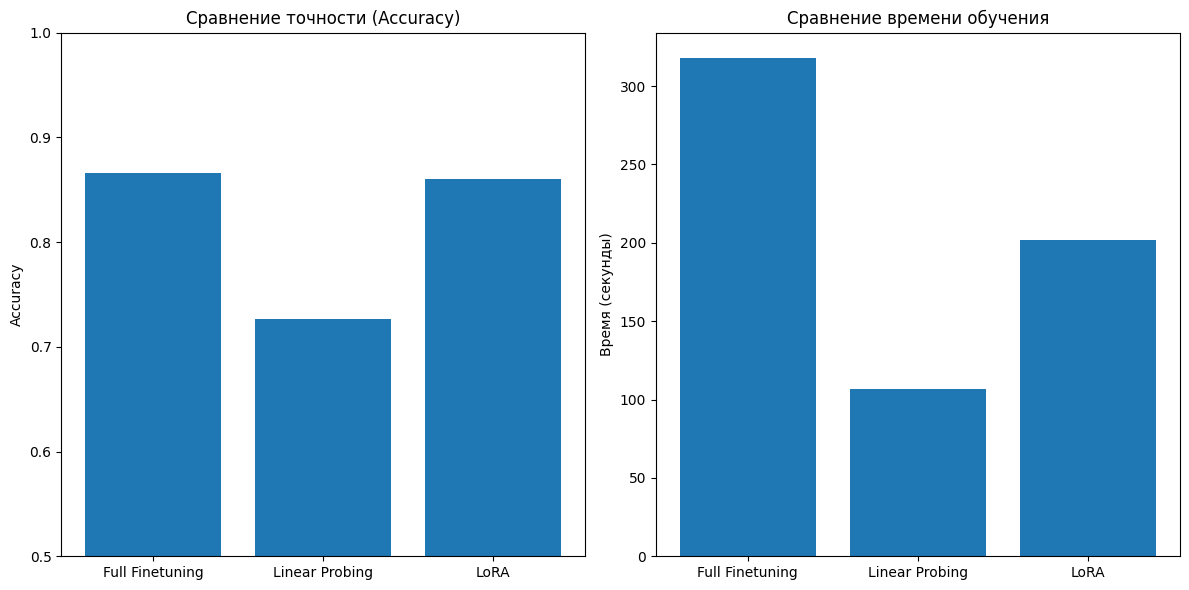

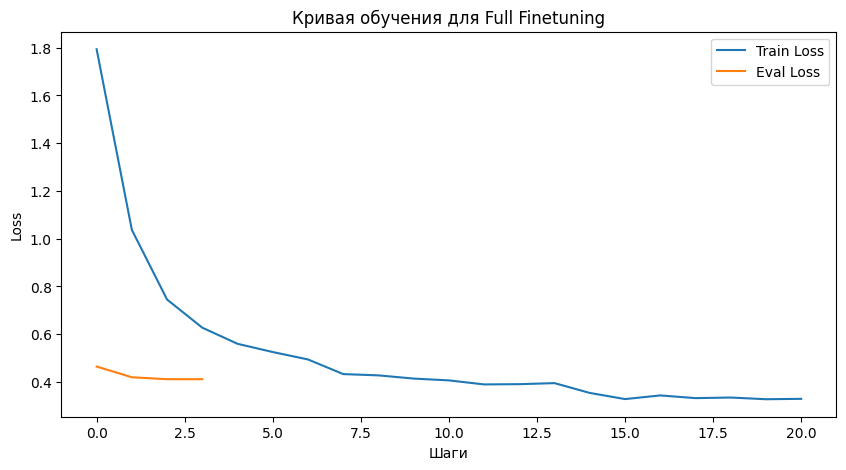

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Метод": ["As-is", "Full Finetuning", "Linear Probing", "LoRA"],
    "Accuracy": [
        results["as_is"]["eval_accuracy"],
        results["full_finetuning"]["eval_accuracy"],
        results["linear_probing"]["eval_accuracy"],
        results["lora"]["eval_accuracy"]
    ],
    "Время обучения (сек)": [
        0,  # As-is не обучалась
        train_results_full.metrics["train_runtime"],
        train_results_lp.metrics["train_runtime"],
        train_results_lora.metrics["train_runtime"]
    ],
    "Обучаемые параметры": [
        "0 (без обучения)",
        f"{sum(p.numel() for p in model_full.parameters() if p.requires_grad):,}",
        f"{sum(p.numel() for p in model_lp.parameters() if p.requires_grad):,}",
        f"{sum(p.numel() for p in model_lora.parameters() if p.requires_grad):,}"
    ]
})

print("Сравнение результатов:")
print(comparison_df.to_string(index=False))

plt.figure(figsize=(12, 6))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.bar(comparison_df["Метод"][1:], comparison_df["Accuracy"][1:])  # Исключаем as-is для наглядности
plt.title("Сравнение точности (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)

# Training time comparison
plt.subplot(1, 2, 2)
plt.bar(comparison_df["Метод"][1:], comparison_df["Время обучения (сек)"][1:])
plt.title("Сравнение времени обучения")
plt.ylabel("Время (секунды)")

plt.tight_layout()
plt.savefig("comparison_results.png")
plt.show()

# Анализ сходимости (пример для полного дообучения)
if hasattr(trainer_full, 'state') and trainer_full.state.log_history:
    train_losses = [log['loss'] for log in trainer_full.state.log_history if 'loss' in log]
    eval_losses = [log['eval_loss'] for log in trainer_full.state.log_history if 'eval_loss' in log]

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(eval_losses, label='Eval Loss')
    plt.title('Кривая обучения для Full Finetuning')
    plt.xlabel('Шаги')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig("learning_curve_full.png")
    plt.show()

Базовая модель (as-is) показала очень низкую точность (7%), так как не обучалась на классификации новостей. Полное дообучение (Full Finetuning) дало лучший результат — 86.6%, но потребовало много времени (5.3 минуты) и ресурсов (29 млн параметров).

LoRA показала почти такой же высокий результат (86.1%), но обучалась быстрее (3.4 минуты) и использовала всего 33 тыс. параметров. Это делает LoRA отличным выбором для баланса качества и скорости.

Linear Probing обучался быстрее всех (1.8 минуты) и использовал минимум параметров (3.4 тыс.), но точность оказалась ниже (72.6%). Этот метод подходит, когда важна скорость, а не максимальное качество.